# Step 1) Feature selection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import SelectKBest
from sklearn.metrics import root_mean_squared_error, r2_score
from feature_engine.selection import MRMR
from qiskit.circuit.library import pauli_feature_map
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

In [ ]:
X = pd.read_csv("../dataset/j_kampe.csv")
y = pd.read_csv("../dataset/distances.csv")["distance"]

X = X[1001:2_001]
y = y[1001:2_001]

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

def plot_top_features(importance: pd.Series, title: str, xlabel: str, ylabel: str) -> None:
    plt.figure(figsize=(10, 6))
    importance.sort_values().plot(kind="barh", color="gray")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

## Correlation

--- Method (i): Correlation Ranking ---


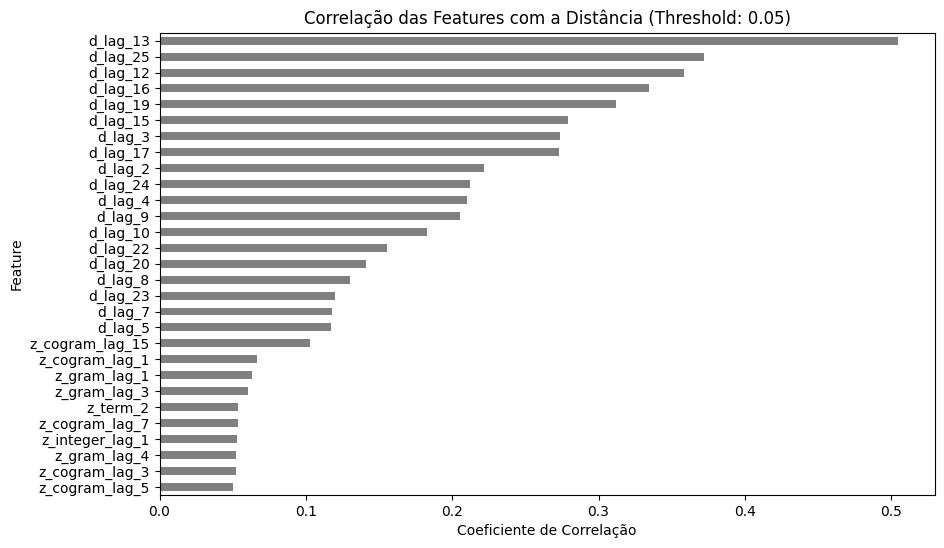

In [ ]:
print("--- Method (i): Correlation Ranking ---")
correlations = X_train.corrwith(y_train)
threshold = 0.05
sorted_correlation_rank = correlations.abs().sort_values(ascending=False)
top_features = sorted_correlation_rank[sorted_correlation_rank > threshold]

top_features.index.to_series().to_csv("../results/experiment_10/correlation_feature_selection.csv", index=False, header=["feature"])

plot_top_features(
    top_features,
    f"Correlação das Features com a Distância (Threshold: {threshold})",
    "Coeficiente de Correlação",
    "Feature"
)

## RandomForest

--- Random Forest Importance Ranking ---


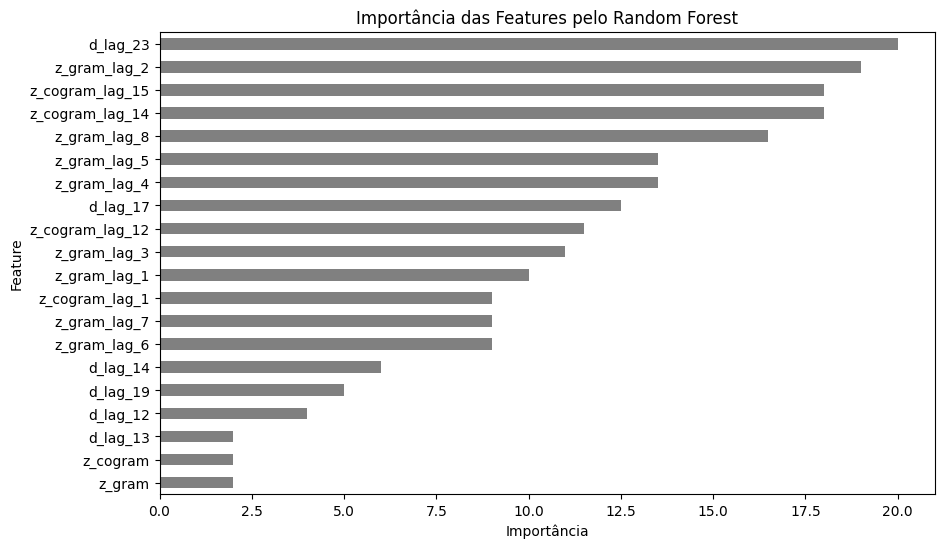

In [35]:
print("--- Random Forest Importance Ranking ---")

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_purity = pd.Series(rf_model.feature_importances_, index=X_train.columns)

perm_result = permutation_importance(rf_model, X_train, y_train, n_repeats=10, random_state=42, n_jobs=1)
rf_accuracy = pd.Series(perm_result.importances_mean, index=X_train.columns)

combined_rank = (rf_purity.rank(ascending=False) + rf_accuracy.rank(ascending=False)) / 2
top_features = combined_rank.nsmallest(20)

result_df = pd.DataFrame({"feature": top_features.sort_values(ascending=False).index})
result_df.to_csv("../results/experiment_10/random_forest_feature_selection.csv", index=False)

plot_top_features(
    top_features,
    "Importância das Features pelo Random Forest",
    "Importância",
    "Feature"
)

## Gevrey Weights Method

--- Method (iii) Neural Network Importance Ranking (Gevrey) ---
gram_lag_10        1.399345
gram_lag_7         1.336191
z_integer          1.319103
z_integer_lag_4    1.290475
d_lag_1            1.269526
                     ...   
z_gram_lag_6       0.853219
z_integer_lag_6    0.843998
z_integer_lag_2    0.815348
d_lag_5            0.800168
z_cogram_lag_3     0.770605
Length: 94, dtype: float64


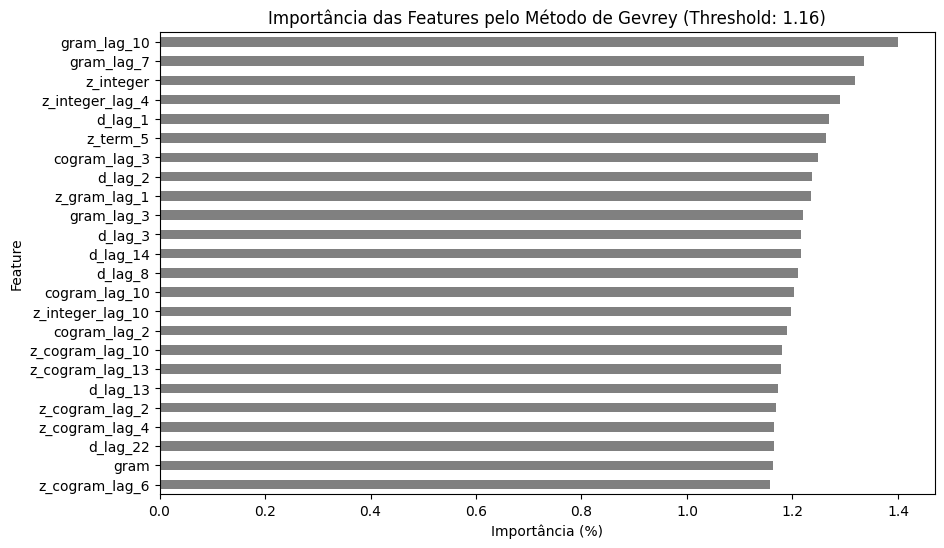

In [36]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_train)

print("--- Method (iii) Neural Network Importance Ranking (Gevrey) ---")

nn_model = MLPRegressor(
    hidden_layer_sizes=(50, 30),
    max_iter=1000,
    random_state=42,
    early_stopping=True
)
nn_model.fit(X_scaled, y_train)

W = nn_model.coefs_[0] # matriz de pesos entre a camada de entrada e a primeira camada oculta
ni = W.shape[0]
nh = W.shape[1]

Q = np.zeros((ni, nh))

for h in range(nh):
    soma_pesos = 0
    for i in range(ni):
        soma_pesos += abs(W[i, h])
    for i in range(ni):
        Q[i, h] = abs(W[i, h]) / soma_pesos

soma_total = 0
for h in range(nh):
    for i in range(ni):
        soma_total += Q[i, h]

RI = np.zeros(ni)

for i in range(ni):
    soma_h = 0
    for h in range(nh):
        soma_h += Q[i, h]
    RI[i] = (soma_h / soma_total) * 100

nn_importance = pd.Series(RI, index=X_train.columns)
nn_importance_sorted = nn_importance.sort_values(ascending=False)

print(nn_importance_sorted)

threshold_nn = np.percentile(RI, 75)
final_ranked_features = nn_importance[nn_importance > threshold_nn].sort_values(ascending=False)

final_ranked_features.index\
    .to_series()\
    .to_csv("../results/experiment_10/gevrey_method_feature_selection.csv", index=False, header=["feature"])

plot_top_features(
    final_ranked_features,
    f"Importância das Features pelo Método de Gevrey (Threshold: {threshold_nn:.2f})",
    "Importância (%)",
    "Feature"
)

## Minimum Redundancy Maxium Relevance

In [37]:
n_features_mrmr = 10
mrmr_selector = MRMR(method="MID", regression=True, max_features=n_features_mrmr)
X_mrmr = mrmr_selector.fit_transform(X, y)
selected_features = X.columns[~X.columns.isin(mrmr_selector.features_to_drop_)]
pd.DataFrame({"feature": selected_features}).to_csv(f"../results/experiment_10/mrmr_{n_features_mrmr}_features.csv", index=False)

## SelectKBest

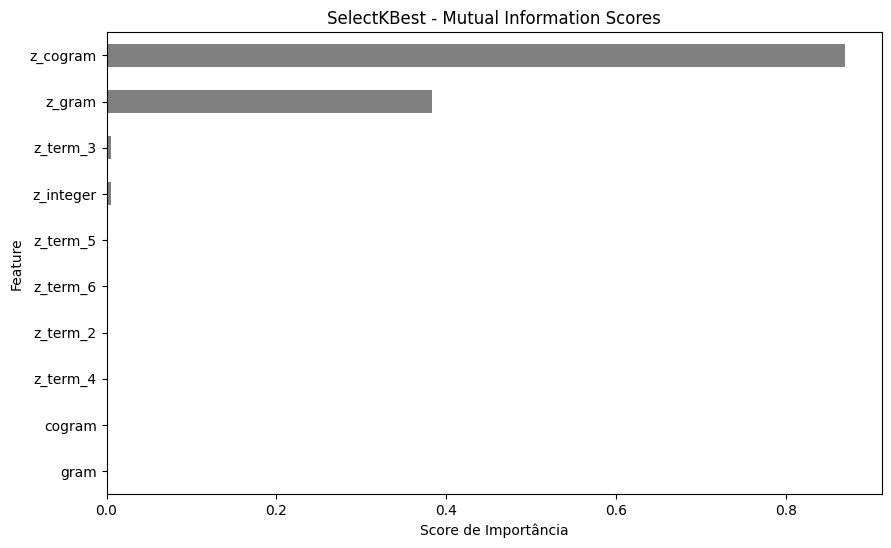

In [38]:
selector = SelectKBest(score_func=mutual_info_regression, k=10)
selector.fit(X_train, y_train)

names = X_train.columns[selector.get_support()]
pd.DataFrame({"feature": names}).to_csv(
    "../results/experiment_10/mi_feature_selection.csv",
    index=False
)

plot_top_features(
    pd.Series(selector.scores_, index=X_train.columns)[:10],
    "SelectKBest - Mutual Information Scores",
    "Score de Importância",
    "Feature"
)

# Step 2) Training Classical SVR

In [4]:
random_forest_features = pd.read_csv("../results/experiment_10/random_forest_feature_selection.csv")["feature"].tolist()
correlation_features = pd.read_csv("../results/experiment_10/correlation_feature_selection.csv")["feature"].tolist()
gevrey_method_features = pd.read_csv("../results/experiment_10/gevrey_method_feature_selection.csv")["feature"].tolist()
mrmr_10_features = pd.read_csv("../results/experiment_10/mrmr_10_features.csv")["feature"].tolist()
mi_features = pd.read_csv("../results/experiment_10/mi_feature_selection.csv")["feature"].tolist()

features_map = {
    "Random Forest": random_forest_features[:10],
    "Correlation": correlation_features[:10],
    "Gevrey Method": gevrey_method_features[:10],
    "MRMR (10 features)": mrmr_10_features,
    "Mutual Information": mi_features
}

In [3]:
def run_classical_experiment(features_map):
    results = []

    param_grid = {
        "svr__C": [0.1, 1, 10, 100],
        "svr__epsilon": [0.001, 0.01, 0.1, 0.5],
        "svr__gamma": ["scale", 0.01, 0.1, 1.0]
    }

    for group_name, features in features_map.items():
        print(f"Running experiment for group: {group_name} with {len(features)} features")

        X_train_subset = X_train[features].to_numpy()
        X_test_subset = X_test[features].to_numpy()

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel="rbf"))
        ])

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_root_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=5),
            n_jobs=-1
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_

        y_pred = best_model.predict(X_test_subset)

        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Group": group_name,
            "RMSE": rmse,
            "R2": r2,
            "Best C": grid.best_params_["svr__C"],
            "Best epsilon": grid.best_params_["svr__epsilon"],
            "Best gamma": grid.best_params_["svr__gamma"],
            "Features": len(features)
        })

    return pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)


In [6]:
df_standard = run_classical_experiment(features_map)
print(df_standard)
df_standard.to_csv("../results/experiment_10/classical_results.csv", index=False)

Running experiment for group: Random Forest with 10 features
Running experiment for group: Correlation with 10 features
Running experiment for group: Gevrey Method with 10 features
Running experiment for group: MRMR (10 features) with 10 features
Running experiment for group: Mutual Information with 10 features
                Group      RMSE        R2  ...  Best epsilon  Best gamma Features
0  Mutual Information  0.115845  0.848639  ...          0.01         0.1       10
1  MRMR (10 features)  0.132908  0.800768  ...          0.01       scale       10
2       Random Forest  0.256220  0.259573  ...          0.10       scale       10
3         Correlation  0.261134  0.230897  ...          0.10        0.01       10
4       Gevrey Method  0.278719  0.123822  ...          0.10        0.01       10

[5 rows x 7 columns]


# Step 3) Traning Quantum SVR using the same best hyperparameters and features of classical SVR using Angle Embedding

In [ ]:
dev = qml.device("default.qubit", wires=10)

@qml.qnode(dev)
def kernel(x1, x2, n_qubits):
    qml.AngleEmbedding(x1, wires=range(n_qubits), rotation="Z")
    qml.adjoint(qml.AngleEmbedding)(x2, wires=range(n_qubits), rotation="Z")
    return qml.expval(qml.Projector([0] * n_qubits, wires=range(n_qubits)))


def kernel_mat(A, B):
    mat = []
    for a in A:
        row = []
        for b in B:
            row.append(kernel(a, b, n_qubits=10))
        mat.append(row)
    return np.array(mat)


results = []
for group_name, features in features_map.items():
    print(f"Running quantum experiment for group: {group_name} with {len(features)} features")
    scaler = MinMaxScaler()
    X_train_subset = X_train[features].to_numpy()
    X_train_scaled = scaler.fit_transform(X_train_subset)
    X_test_subset = X_test[features].to_numpy()
    X_test_scaled = scaler.transform(X_test_subset)

    svr = SVR(kernel=kernel_mat)
    svr.fit(X_train_scaled, y_train)
    y_pred = svr.predict(X_test_scaled)

    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append( {
        "Group": f"Quantum Kernel SVR - {group_name} Features",
        "RMSE": rmse,
        "R2": r2,
        "qubits": 10,
    })

df_quantum = pd.DataFrame(results)
print(df_quantum)
df_quantum.to_csv("../results/experiment_10/quantum_angle_embedding_results.csv", index=False)

Running quantum experiment for group: Random Forest with 10 features
RMSE: 0.27199575646656227
R2: 0.1655848106516158
Running quantum experiment for group: Correlation with 10 features
RMSE: 0.2603097944126866
R2: 0.2357438140139726
Running quantum experiment for group: Gevrey Method with 10 features
RMSE: 0.2846616281808995
R2: 0.08606396239096359
Running quantum experiment for group: MRMR (10 features) with 10 features
RMSE: 0.24118452741896684
R2: 0.3439199516390449
Running quantum experiment for group: Mutual Information with 10 features
RMSE: 0.23290089302706082
R2: 0.38821298938569493


# Step 4) Traning Quantum SVR using the same best hyperparameters and features of classical SVR using PauliFeatureMap

In [ ]:
def create_quantum_kernel(n_qubits, reps=2, entanglement="linear"):
    feature_map = pauli_feature_map(feature_dimension=n_qubits, reps=reps, entanglement=entanglement)
    sampler = StatevectorSampler()
    fidelity = ComputeUncompute(sampler=sampler)
    quantum_kernel = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)
    return quantum_kernel


results = []

for group_name, features in features_map.items():
    print(f"Running quantum experiment with Pauli Feature Map for group: {group_name} with {len(features)} features")
    scaler = StandardScaler()
    X_train_subset = X_train[features].to_numpy()
    X_train_scaled = scaler.fit_transform(X_train_subset)
    X_test_subset = X_test[features].to_numpy()
    X_test_scaled = scaler.transform(X_test_subset)

    quantum_kernel = create_quantum_kernel(n_qubits=10)
    svr = SVR(kernel=quantum_kernel.evaluate, C=10, epsilon=0.01)
    svr.fit(X_train_scaled, y_train)
    y_pred = svr.predict(X_test_scaled)

    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Group": f"Quantum Kernel SVR - {group_name} Features",
        "RMSE": rmse,
        "R2": r2,
        "qubits": 10,
    })

df_quantum = pd.DataFrame(results)
print(df_quantum)
df_quantum.to_csv("../results/experiment_10/quantum_pauli_feature_map_results.csv", index=False)

RMSE: 0.2345789564278184
R2: 0.37936531349395786
